In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
base_dir_path = "/srv/beegfs/scratch/groups/rodem/lumea/datasets/aspenJets"
file_name = "RunG_batch0.h5"
file_path = os.path.join(base_dir_path, file_name)

In [4]:
import h5py

h5_file = h5py.File(file_path, "r")

# Display the file structure
def show_structure(name, obj):
    print(f"{name}: {type(obj).__name__}")

h5_file.visititems(show_structure)

PFCands: Dataset
event_info: Dataset
jet_kinematics: Dataset
jet_tagging: Dataset


In [5]:
n_events = 1_000
constits = h5_file["PFCands"][:n_events]

In [6]:
feature_names = ['px', 'py', 'pz', 'E', 'd0', 'd0Err', 'dz', 'dzErr', 'charge', 'PDG_ID', 'PUPPI_weight']
dtype = np.dtype([(name, constits.dtype) for name in feature_names])
constits_named = np.empty(constits.shape[:-1], dtype=dtype)
for i, name in enumerate(feature_names):
    constits_named[name] = constits[..., i]


In [7]:
constits_named.shape

(1000, 150)

In [8]:
constits_named['px'].shape

(1000, 150)

In [9]:
np.unique(constits_named['PDG_ID'])

array([-211.,  -13.,  -11.,    0.,   11.,   13.,   22.,  130.,  211.],
      dtype=float32)

In [10]:
jets = h5_file["jet_kinematics"][:n_events]

In [11]:
jets_feature_names = ['pt', 'eta', 'phi', 'softdrop_mass']
dtype = np.dtype([(name, jets.dtype) for name in jets_feature_names])
jets_named = np.empty(jets.shape[:-1], dtype=dtype)
for i, name in enumerate(jets_feature_names):
    jets_named[name] = jets[..., i]


In [12]:
# calculate derived particle kinematics: pt,
constits_pt = np.sqrt(constits_named['px']**2 + constits_named['py']**2)
constits_p   = np.sqrt(constits_named['px']**2 + constits_named['py']**2 + constits_named['pz']**2)
constits_phi = np.arctan2(constits_named['py'], constits_named['px'])
with np.errstate(divide='ignore', invalid='ignore'):
    constits_eta = np.where(constits_p > 0, np.arctanh(np.clip(constits_named['pz'] / np.where(constits_p > 0, constits_p, 1), -1 + 1e-8, 1 - 1e-8)), 0.0) # clip particle along beam axis

In [13]:
# calculate derived patricle kinematics delta-eta, delta-phi
constits_deta = np.where(
    jets_named['pt'][:, None] > 0,
    jets_named['eta'][:, None] - constits_eta,
    -(jets_named['eta'][:, None] - constits_eta),
)
constits_dphi = (jets_named['phi'][:, None] - constits_phi + np.pi) % (2*np.pi) - np.pi   # wrap to [-pi, pi]

In [14]:
m2 = constits_named['E']**2 - (constits_named['px']**2 + constits_named['py']**2 + constits_named['pz']**2)
constits_mass = np.sqrt(np.clip(m2, 0, None))   # clip guards against tiny negative values from float rounding, e.g. for near-massless photons

In [15]:
def pid_flags(pdg_id):
    a = np.abs(pdg_id).astype(np.int32)
    # 211: is charged hadron, 130: is neutral hadron, 22: is photon, 11: is electron, 13: is muon
    return [(a==211).astype(int), (a==130).astype(int), (a==22).astype(int), (a==11).astype(int), (a==13).astype(int)]


In [16]:
pid_flags(11.)

[np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0)]

In [17]:
type(pid_flags(11.)[0])

numpy.int64

In [18]:
constits_is_charged_hadron, constits_is_neutral_hadron, constits_is_photon, constits_is_electron, constits_is_muon = pid_flags(constits_named['PDG_ID'])
constits_is_electron.shape  # same shape as constits_named['PDG_ID'], e.g. (1000, 150)

(1000, 150)

In [19]:
import sys

deps_path = "/home/users/w/wozniak/.local/ntp4jets-deps"
if deps_path not in sys.path:
    sys.path.insert(0, deps_path)

In [20]:
import heputl.plotting.oneD as heplt

ValueError: The 'color' keyword argument must have one color per dataset, but 150 datasets and 1 colors were provided

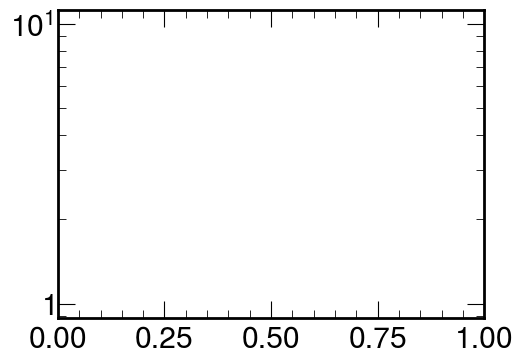

In [ ]:
labels = ['aspen open jets']
dats = [constits_pt.flatten()]
heplt.plot_feature_hist_for_n_samples(
    data=dats,
    sample_names=labels,
    xlabel='particle pt',
    bins=70,
    show_plt=True,
    legend_outside=False
)